## Imports

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import scipy.linalg as la

## Helper functions - extract disk and approximate conformal mapping

In [21]:
def extract_disk_from_file(filename):
    """
    Read a square-lattice disk from a text file and extract its interior
    and boundary geometry.

    The file is assumed to contain the lattice squares together with their
    neighbor indices, followed by the ordered list of boundary edges.
    Each square is represented by its lattice coordinates (x, y) and the
    indices of its neighboring squares, where -1 denotes a missing neighbor
    and therefore a boundary side.

    Returns
    -------
    squares : list
        List of squares represented by (x, y, neighbors).

    boundary_coords : np.ndarray
        Coordinates of the two endpoints of each boundary edge.

    boundary_mids : np.ndarray
        Coordinates of the midpoint of each boundary edge.

    boundary : np.ndarray
        Ordered list of boundary edges. Each boundary edge is represented by
        (square_index, side), where side specifies which side of the square
        lies on the boundary.
    """

    with open(filename, "r") as f:
        lines = f.readlines()

    n_squares = int(lines[0])
    squares = []

    # square data
    for i in range(1, n_squares + 1):
        parts = list(map(int, lines[i].strip().split()))
        x, y = parts[0], parts[1]
        neighbors = parts[2:]
        squares.append((x, y, neighbors))

    # boundary data
    n_boundary = int(lines[n_squares + 1])
    boundary = []

    for i in range(n_squares + 2, n_squares + 2 + n_boundary):
        boundary.append(tuple(map(int, lines[i].strip().split())))

    # boundary geometry
    boundary_coords = []
    boundary_mids = []

    for idx, side in boundary:
        x, y, neighbors = squares[idx]

        if side == 0:  # east
            coords = [
                (x + 0.5, y - 0.5),
                (x + 0.5, y + 0.5)
            ]
            middle = np.array([x + 0.5, y])

        elif side == 1:  # north
            coords = [
                (x - 0.5, y + 0.5),
                (x + 0.5, y + 0.5)
            ]
            middle = np.array([x, y + 0.5])

        elif side == 2:  # west
            coords = [
                (x - 0.5, y - 0.5),
                (x - 0.5, y + 0.5)
            ]
            middle = np.array([x - 0.5, y])

        elif side == 3:  # south
            coords = [
                (x - 0.5, y - 0.5),
                (x + 0.5, y - 0.5)
            ]
            middle = np.array([x, y - 0.5])

        boundary_coords.append(coords)
        boundary_mids.append(middle)

    return (
        squares,
        np.array(boundary_coords),
        np.array(boundary_mids),
        np.array(boundary)
    )


def boundary_side_count_matrix(squares):
    """
    Construct a diagonal matrix containing the number of boundary sides
    of each square.

    Returns
    -------
    scipy.sparse.csc_matrix
        Diagonal matrix whose i-th entry gives the number of boundary
        sides of square i.
    """

    boundary_side_counts = []

    for x, y, neighbors in squares:
        boundary_side_counts.append(neighbors.count(-1))

    return sp.diags(boundary_side_counts, format="csc", dtype=int)


def graph_laplacian(squares):
    """
    Construct the graph Laplacian for the square-lattice disk.

    The Laplacian is defined as Delta = 4I - A, where A is the adjacency
    matrix of the squares. 

    Returns
    -------
    scipy.sparse matrix
        Graph Laplacian of the lattice disk
    """

    n = len(squares)

    A = sp.lil_matrix((n, n))
    I = sp.identity(n)

    for i, square in enumerate(squares):
        x, y, neighbors = square
        for neighbor in neighbors:
            if neighbor != -1:
                A[i, neighbor] = 1
                A[neighbor, i] = 1

    return 4 * I - A


def inverse_laplacian(laplacian):
    """
    Compute the inverse of the graph Laplacian.

    Returns
    -------
     scipy.sparse matrix
        Inverse of graph Laplacian

    """

    return spla.inv(sp.csc_matrix(laplacian))


def start_vertex(inverse_laplacian):
    """
    Choose the square used as the origin of the discrete conformal map.

    The selected square is the one with the largest row sum of the inverse
    Laplacian, corresponding to the largest expected exit time.

    Returns
    -------
    int
        Index of the selected starting square
    """

    row_sums = inverse_laplacian.sum(axis=1)

    return np.argmax(row_sums)


def harmonic_measure_by_inverse(start_x, lambda_matrix, inv_laplacian):
    """
    Compute the harmonic measure of the boundary squares as seen from
    a chosen starting square.

    Returns
    -------
    np.ndarray
        Harmonic measure assigned to each square
    """

    row = inv_laplacian.getrow(start_x)
    product = row @ lambda_matrix

    return product.toarray().ravel()


def probs_per_edge_ordered(squares, probs, boundary):
    """
    Convert harmonic measures of boundary squares into harmonic measures
    of individual boundary edges.

    The probability of a boundary square is divided equally among its
    exposed boundary sides. Probabilities are returned in the same order
    as the boundary-edge list.

    Returns
    -------
    np.ndarray
        Harmonic measure of each ordered boundary edge
    """

    edge_probs = []

    for idx, side in boundary:
        n_boundary_sides = squares[idx][2].count(-1)
        edge_probs.append(probs[idx] / n_boundary_sides)

    return np.array(edge_probs, dtype=float)


def boundary_midpoint_preimages(edge_probs):
    """
    Map the ordered boundary edges to preimages on the unit circle.

    Each boundary edge corresponds to an arc whose angular size is
    proportional to its harmonic measure. The midpoint of each arc is
    used as the representative boundary preimage.

    Returns
    -------
    np.ndarray
        Complex coordinates w_j on the unit circle
    """

    edge_probs = np.asarray(edge_probs, dtype=float)
    cumulative = np.cumsum(edge_probs)
    angles = np.concatenate(([0.0], 2 * np.pi * cumulative))
    mid_angles = 0.5 * (angles[:-1] + angles[1:])

    return np.exp(1j * mid_angles)


def construct_B(squares, boundary):
    """
    Construct the incidence matrix between lattice squares and boundary edges.

    The entry B[i, j] is 1 when boundary edge j belongs to square i,
    and 0 otherwise.

    Returns
    -------
    scipy.sparse.lil_matrix
        Square-to-boundary-edge incidence matrix
    """

    n = len(squares)
    m = len(boundary)

    B = sp.lil_matrix((n, m))

    for i, square in enumerate(squares):
        x, y, neighbors = square

        for j, edge in enumerate(boundary):
            idx, side = edge

            if idx == i:
                B[i, j] = 1

    return B


def solve_dirichlet_problem(laplacian, B, w):
    """
    Solve the discrete Dirichlet problem for the harmonic extension of
    the boundary preimages into the lattice disk.

    The interior values satisfy

        Delta z = -B w,

    where w are the boundary values on the unit circle.

    Returns
    -------
    np.ndarray
        Complex coordinates z_i in the unit circle interior associated with the lattice square centers
    """

    rhs = -B @ w

    return spla.spsolve(laplacian, rhs)


def square_centers_complex(squares):
    """
    Convert the lattice square centers to complex coordinates.

    Returns
    -------
    np.ndarray
        Complex lattice coordinates u_i = x_i + i y_i
    """

    u = np.zeros(len(squares), dtype=complex)

    for i, (x, y, neighbors) in enumerate(squares):
        u[i] = x + 1j * y

    return u


def inside_radius(z_values, u_values, squares, radius):
    """
    Select mapping pairs whose disk coordinates lie within a given
    effective radius.

    Returns
    -------
    z_r : np.ndarray
        Disk coordinates satisfying |z| <= radius
    u_r : np.ndarray
        Corresponding lattice coordinates
    squares_r : list
        Squares corresponding to the selected points
    index_map : dict
        Mapping from original square indices to indices in the reduced set
    """

    mask = np.abs(z_values) <= radius
    kept_indices = np.where(mask)[0]

    z_r = z_values[kept_indices]
    u_r = u_values[kept_indices]
    squares_r = [squares[i] for i in kept_indices]
    index_map = {old: new for new, old in enumerate(kept_indices)}

    return z_r, u_r, squares_r, index_map


def evaluate_polynomial(z, coeffs):
    """
    Evaluate a holomorphic polynomial at one or more complex points.

    The polynomial is

        F(z) = a_0 + a_1 z + ... + a_n z^n.


    Returns
    -------
    complex or np.ndarray
        Evaluated polynomial values F(z)
    """

    return sum(c * z**k for k, c in enumerate(coeffs))


def fit_holomorphic_polynomial(z_values, u_values, degree):
    """
    Fit a holomorphic polynomial mapping from disk coordinates to
    lattice coordinates using complex least squares.

    The fitted map has the form

        F(z) = a_0 + a_1 z + ... + a_degree z^degree.


    Returns
    -------
    coeffs : np.ndarray
        Complex polynomial coefficients (a_0, ..., a_degree)
    residual : float
        Least-squares residual of the fitted map
    """

    #vandermonde matrix
    V = np.vander(z_values, N=degree + 1, increasing=True)
    coeffs, _, _, _ = la.lstsq(V, u_values)

    u_fit = V @ coeffs
    residual = la.norm(u_values - u_fit) / la.norm(u_values)

    return coeffs, residual


def discrete_disk_mapping(filename):
    """
    Construct the discrete harmonic map from a square-lattice disk to the unit disk.


    Returns
    -------
    dict:
        Dictionary containing the geometry and discrete mapping data:
            squares : list
            boundary_coords : np.ndarray
            boundary_mids : np.ndarray
            boundary : np.ndarray
            start_idx : int
            edge_probs : np.ndarray
            w : np.ndarray
            z : np.ndarray
            u : np.ndarray

    """

    # load disk
    squares, boundary_coords, boundary_mids, boundary = extract_disk_from_file(filename)

    # build matrices
    Lambda = boundary_side_count_matrix(squares)
    Delta = graph_laplacian(squares)
    Delta_inv = inverse_laplacian(Delta)

    # choose starting square
    start_idx = start_vertex(Delta_inv)

    # harmonic measure
    square_probs = harmonic_measure_by_inverse(
        start_idx,
        Lambda,
        Delta_inv
    )

    edge_probs = probs_per_edge_ordered(
        squares,
        square_probs,
        boundary
    )

    # boundary pre-images on the unit circle
    w = boundary_midpoint_preimages(edge_probs)

    # harmonic extension to the interior
    B = construct_B(squares, boundary)
    z_values = solve_dirichlet_problem(Delta, B, w)

    # lattice coordinates
    u_values = square_centers_complex(squares)

    return {
        "squares": squares,
        "boundary_coords": boundary_coords,
        "boundary_mids": boundary_mids,
        "boundary": boundary,
        "start_idx": start_idx,
        "edge_probs": edge_probs,
        "w": w,
        "z": z_values,
        "u": u_values
    }

def fit_inverse_map(z_values, u_values, squares, radius, degree):
    """
    Fit a polynomial approximation

        F(z) = a_0 + a_1 z + ... + a_degree z^degree

    to the inverse map from the unit disk to the lattice disk,
    using points with |z| <= radius.

    Returns
    -------
    dict:
        Dictionary containing the fitted inverse map and the data used in the fit:

        coeffs : np.ndarray
            Complex coefficients (a_0, ..., a_degree) of the fitted polynomial
            F(z) = a_0 + a_1 z + ... + a_degree z^degree

        residual : float
            Least-squares residual of the polynomial fit

        z_fit : np.ndarray
            Complex preimages z_i within the specified effective radius

        u_true : np.ndarray
            Complex coordinates u_i of the lattice square centers corresponding
            to the preimages z_i

        u_fit : np.ndarray
            Images F(z_i) of the selected preimages under the fitted polynomial
    """

    # select points within the effective radius
    z_r, u_r, _, _ = inside_radius(
        z_values,
        u_values,
        squares,
        radius
    )

    # check that there are enough points
    if len(z_r) < degree + 1:
        raise ValueError(
            f"Only {len(z_r)} points lie inside r={radius}, "
            f"but {degree + 1} coefficients must be fitted."
        )

    # fit polynomial
    coeffs, residual = fit_holomorphic_polynomial(
        z_r,
        u_r,
        degree
    )

    # evaluate fitted map
    u_fit = evaluate_polynomial(z_r, coeffs)

    return {
        "coeffs": coeffs,
        "residual": residual,
        "z_fit": z_r,
        "u_true": u_r,
        "u_fit": u_fit
    }



## Helper functions - visualise disk and conformal mapping

In [22]:
def plot_disk(squares, boundary_coords, square_scale=1.0, highlight_square=None, show_grid=False, show_square_centers=False, center_size=20, save_path=None):
    """
    Plot a square-lattice disk together with its boundary.

    """

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_aspect("equal")

    x_coords = [square[0] for square in squares]
    y_coords = [square[1] for square in squares]

    x_min = int(np.floor(min(x_coords))) - 1
    x_max = int(np.ceil(max(x_coords))) + 2
    y_min = int(np.floor(min(y_coords))) - 1
    y_max = int(np.ceil(max(y_coords))) + 2

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # grid
    if show_grid:
        ax.set_xticks(range(x_min, x_max))
        ax.set_yticks(range(y_min, y_max))
        ax.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.5)

    # lattice squares
    for i, (x, y, neighbors) in enumerate(squares):

        if i == highlight_square:
            facecolor = "red"
            alpha = 0.4
        else:
            facecolor = "C0"
            alpha = 0.3

        corner = (x - 0.5 * square_scale, y - 0.5 * square_scale)

        ax.add_patch(plt.Rectangle(corner, square_scale, square_scale, facecolor=facecolor, edgecolor="none", alpha=alpha))

    # square centers
    if show_square_centers:
        ax.scatter(x_coords, y_coords, s=center_size, color="black", zorder=3)

    # highlighted square center
    if highlight_square is not None:
        x0, y0, _ = squares[highlight_square]

        ax.scatter([x0], [y0], s=center_size * 2, color="red", zorder=4)

    # boundary
    for coords in boundary_coords:
        ax.plot(coords[:, 0], coords[:, 1], color="black", linewidth=0.6)

    ax.set_xlabel("Re")
    ax.set_ylabel("Im")

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.tight_layout()

    # save figure
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


def plot_inverse_map_image(z_values, w, u_values, coeffs, radius=None, save_path=None):
    """
    Plot the preimages in the unit disk and their images under the
    approximated conformal map.

    If radius is specified, only interior points with |z| <= radius
    are shown.

    If radius is None, all interior and boundary points are shown.
    """

    # select points
    if radius is None:
        z_plot = z_values
        u_plot = u_values
        show_boundary = True

    else:
        mask = np.abs(z_values) <= radius
        z_plot = z_values[mask]
        u_plot = u_values[mask]
        show_boundary = False

    # evaluate estimated conformal map
    F_z = evaluate_polynomial(z_plot, coeffs)

    # create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # left: unit disk
    theta = np.linspace(0, 2 * np.pi, 500)

    ax1.plot(np.cos(theta), np.sin(theta), color="black", linewidth=1)
    ax1.scatter(np.real(z_plot), np.imag(z_plot), color="C0", label=r"pre-images $z_i$")

    if show_boundary:
        ax1.scatter(np.real(w), np.imag(w), color="C1", label=r"pre-images $w_i$")

    ax1.set_xlabel("Re")
    ax1.set_ylabel("Im")
    ax1.set_aspect("equal")
    ax1.legend()

    # right: lattice disk
    ax2.scatter(np.real(u_plot), np.imag(u_plot), marker="x", color="black", s=45, label=r"lattice points $u_i$")
    ax2.scatter(np.real(F_z), np.imag(F_z), color="C0", label=r"$\tilde{F}(z_i)$")

    if show_boundary:
        F_w = evaluate_polynomial(w, coeffs)

        ax2.scatter(np.real(F_w), np.imag(F_w), color="C1", label=r"$\tilde{F}(w_i)$")

    ax2.set_xlabel("Re")
    ax2.set_ylabel("Im")
    ax2.set_aspect("equal")
    ax2.legend()

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

## Example disk plot

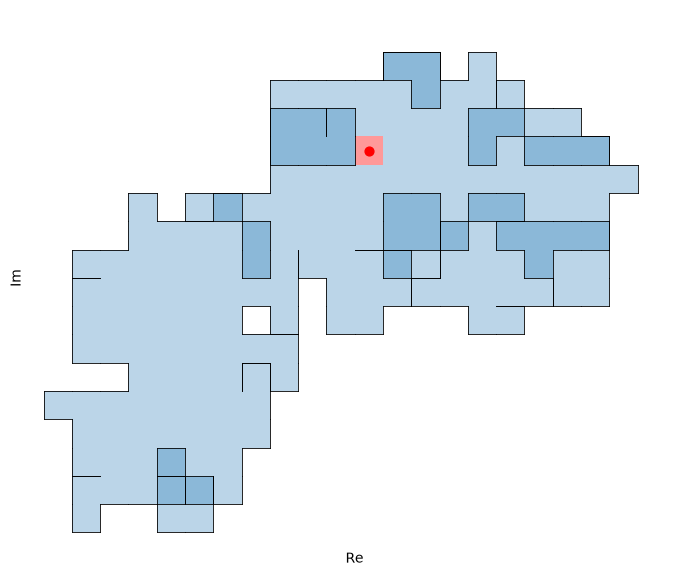

In [23]:
filename = "data/latticediskh100.txt"

# compute discrete disk mapping
data = discrete_disk_mapping(filename)

# plot lattice disk
plot_disk(data["squares"], data["boundary_coords"], highlight_square=data["start_idx"], show_square_centers=False)

Residual: 0.0150791

a_0 = (-4.022799801058549+0.001663223376686756j)
a_1 = (-3.764015705755348+0.3956962451680499j)
a_2 = (0.030777757749025796+0.410897159181128j)
a_3 = (-0.22966423877790482+0.7610953589880562j)
a_4 = (0.3198476981002276-0.5980277642898996j)
a_5 = (-0.03122709890979863+0.0015144715116051396j)
a_6 = (0.37293944747192825-0.11693664244991114j)
a_7 = (-0.25418709967498815+0.030538245138721144j)
a_8 = (-0.455539882378564+0.4937920230868935j)


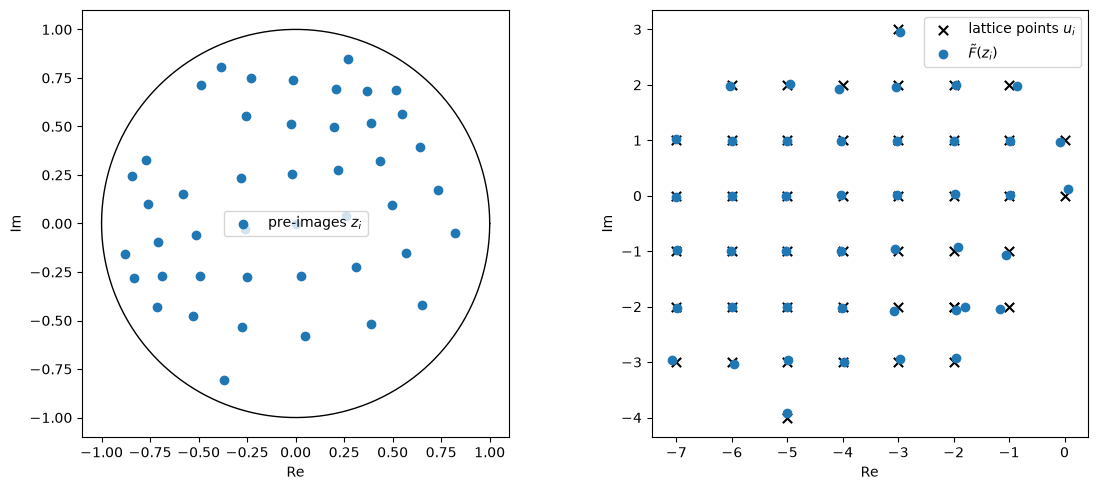

In [24]:
# choose effective radius and polynomial degree of the expansion of F
radius = 0.9
degree = 8


# fit conformal map
fit = fit_inverse_map(data["z"], data["u"], data["squares"], radius, degree)

# print coefficients
print(f"Residual: {fit['residual']:.6g}")
print()

for n, coeff in enumerate(fit["coeffs"]):
    print(f"a_{n} = {coeff}")

# plot discrete map together with the image under the expansion
# the boundary is shown only for radius=None
plot_inverse_map_image(data["z"], data["w"], data["u"], fit["coeffs"], radius=radius)

In [ ]:
# Optional: build the coefficient files used in ch3_fourier_analysis.
# This cell is not needed for the plots above. Run it only to (re)generate
# data/coefficients_r*_m*.h5 from the disk ensembles, which takes a while:
# every disk is mapped once and then fitted at each effective radius.
# This cell assumes the disk ensembles for the approximate perimeters
# m in {50, 100, 200, 500, 1000, 2000} are stored in "disk_ensembles/ensemble_m{m}".
# Generate them first, or change the path below.

import h5py
from pathlib import Path

ENSEMBLE_DIR = Path("../disk_ensembles") 
OUTPUT_DIR = Path("../ch3_fourier_analysis/data")

PERIMETERS = [50, 100, 200, 500, 1000, 2000]
RADII = [0.6, 0.7, 0.8, 0.9]
DEGREE = 8


def fit_ensemble(perimeter, radii=RADII, degree=DEGREE):
    """
    Fit the conformal map of every disk in one ensemble, at each of the
    effective radii.

    Disks for which fewer than degree + 1 preimages lie inside a radius
    are skipped for that radius only.

    Returns
    -------
    dict
        Dictionary indexed by radius, containing the fitted coefficients,
        the residuals and the names of the disks used
    """

    directory = ENSEMBLE_DIR / f"ensemble_m{perimeter}"

    files = sorted(directory.glob("disk_*.txt"))

    if not files:
        raise FileNotFoundError(f"No disks found in {directory.resolve()}")

    results = {r: {"coefficients": [], "residuals": [], "files": []} for r in radii}

    for i, filename in enumerate(files):

        # the discrete map does not depend on the radius, so it is
        # computed once per disk and reused for all radii
        data = discrete_disk_mapping(str(filename))

        for r in radii:

            try:
                fit = fit_inverse_map(data["z"], data["u"], data["squares"], r, degree)
            except ValueError:
                continue

            results[r]["coefficients"].append(fit["coeffs"])
            results[r]["residuals"].append(fit["residual"])
            results[r]["files"].append(filename.name)

        if (i + 1) % 25 == 0 or i + 1 == len(files):
            print(f"  m = {perimeter}: {i + 1}/{len(files)} disks", flush=True)

    return results


def write_coefficient_file(perimeter, radius, result, degree=DEGREE):
    """
    Store the fitted coefficients of one ensemble at one effective radius,
    in the format read by ch3_fourier_analysis/disk_mapping_fourier.ipynb.

    Returns
    -------
    pathlib.Path
        Path of the file written
    """

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    path = OUTPUT_DIR / f"coefficients_r{radius:g}_m{perimeter}.h5"

    with h5py.File(path, "w") as f:

        f.create_dataset("coefficients", data=np.array(result["coefficients"], dtype=complex))
        f.create_dataset("residuals", data=np.array(result["residuals"], dtype=float))

        f.attrs["fit_radius"] = radius
        f.attrs["perimeter"] = perimeter
        f.attrs["degree"] = degree
        f.attrs["n_disks"] = len(result["coefficients"])

    return path


def build_coefficient_files(perimeters=PERIMETERS, radii=RADII, degree=DEGREE):
    """
    Build the coefficient files for all ensembles and effective radii.

    Returns
    -------
    None
    """

    for perimeter in perimeters:

        results = fit_ensemble(perimeter, radii, degree)

        for r in radii:

            path = write_coefficient_file(perimeter, r, results[r], degree)

            n_fitted = len(results[r]["coefficients"])

            print(f"  wrote {path} ({n_fitted} disks)")


build_coefficient_files()